# Convolutional Neural Networks implementation using PyTorch

In [1]:
!pip install torch torchvision matplotlib

## Configuração de Ambiente e Hiperparâmetros:


Este bloco inicializa o ambiente de desenvolvimento, definindo os recursos computacionais e as constantes globais que guiarão o treinamento.

* Seleção de Dispositivo: Configura o `DEVICE` para utilizar GPU (CUDA) se disponível, garantindo a eficiência no processamento de tensores.

* Hiperparâmetros: Define o `BATCH_SIZE` em 64 para equilibrar o uso de memória e a estabilidade do gradiente, e o `LR` (taxa de aprendizado) em 1e-3 para o otimizador Adam.

* Bibliotecas: Importa as ferramentas fundamentais: `torch` para a lógica de tensores, `torchvision` para acesso aos datasets e modelos pré-treinados, e `matplotlib` para visualização dos resultados.  

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64
EPOCHS     = 15
LR         = 1e-3

## Pipelines de Dados (DataLoaders)

Implementa o carregamento e a preparação dos dados para o MNIST e o CIFAR-10 através da biblioteca `torchvision`.  

* MNIST: Como é um dataset simples de dígitos em escala de cinza, utiliza apenas normalização com média (0.1307) e desvio padrão (0.3081) específicos do dataset para estabilizar o treinamento.

* CIFAR-10 (Data Augmentation): Para lidar com a alta variância de imagens naturais, aplica-se `RandomHorizontalFlip` e `RandomCrop`, o que dobra a diversidade efetiva dos dados e torna a rede mais robusta a translações e espelhamentos.

* Normalização RGB: No CIFAR-10, a normalização é feita por canal (R, G, B) para manter as ativações em uma escala compatível com o esperado pelas redes convolucionais.

In [3]:
def get_mnist_loaders():
    """
    MNIST: escala de cinza 28×28, 10 classes de dígitos.
    Normalização com média/desvio do dataset para estabilizar o gradiente.
    Sem augmentation agressiva — MNIST é simples e limpo.
    """
    tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    train = torchvision.datasets.MNIST(root="./data", train=True,  download=True, transform=tf)
    test  = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=tf)
    return (DataLoader(train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2),
            DataLoader(test,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2))


def get_cifar10_loaders():
    """
    CIFAR-10: RGB 32×32, 10 classes naturais.
    Data Augmentation (flip + crop aleatório):
      - RandomHorizontalFlip: cria invariância a espelhamento horizontal,
        dobra efetivamente o tamanho do dataset sem custo de coleta.
      - RandomCrop(32, padding=4): simula pequenas translações, forçando a
        rede a aprender features robustas à posição do objeto.
    Normalização com estatísticas do CIFAR-10 (média/desvio por canal RGB).
    """
    tf_train = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2023, 0.1994, 0.2010))
    ])
    tf_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2023, 0.1994, 0.2010))
    ])
    train = torchvision.datasets.CIFAR10(root="./data", train=True,  download=True, transform=tf_train)
    test  = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=tf_test)
    return (DataLoader(train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2),
            DataLoader(test,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2))

## Arquiteturas das CNNs Customizadas

Define as classes das redes convolucionais adaptadas para a complexidade de cada tarefa.

**CNN_MNIST**:

* **Estrutura**: Utiliza dois blocos convolucionais seguidos de camadas densas.

* **Regularização**: Aplica ``Dropout`` leve (0.25) nas convoluções para evitar co-adaptação e ``Weight Decay`` (L2) no otimizador para penalizar pesos excessivos, garantindo que a rede não memorize o fundo limpo do MNIST.

**CNN_CIFAR-10**:

* **Profundidade**: Três blocos convolucionais com filtros crescentes (32→64→128) para capturar uma hierarquia de features mais rica (bordas, texturas e objetos).

* **Batch Normalization**: Introduzido após cada convolução para combater o internal covariate shift, acelerando a convergência e permitindo taxas de aprendizado mais altas.

* **Dropout (0.3/0.5)**: Configuração mais agressiva para lidar com o risco de overfitting inerente à complexidade do CIFAR-10.

In [4]:
class CNN_MNIST(nn.Module):
    """
    Arquitetura simples para MNIST (imagens grayscale 28×28).

    Justificativa de regularização:
    ─────────────────────────────────────────────────────────────────────────
    • Weight Decay (L2): penaliza pesos grandes ao somar λ·||w||² à loss.
      Evita que a rede memorize padrões específicos do treino. Implementado
      no otimizador (weight_decay=1e-4). Valor conservador pois MNIST é
      tarefa simples — decay excessivo prejudicaria convergência.

    • Dropout leve (p=0.25 conv / p=0.5 fc): desativa neurônios aleatórios
      durante o treino, forçando redundância de representação. Dropout mais
      pesado nas camadas densas, onde overfitting tende a ser maior.
      Valor baixo nas convoluções para não destruir mapas de features
      espaciais compactos (28×28 já é pequeno).

    Fluxo: Conv→ReLU→Pool → Conv→ReLU→Pool → FC → saída (10 classes)
    """
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Bloco 1: extrai bordas e texturas simples
            nn.Conv2d(1, 32, kernel_size=3, padding=1),   # 28×28→28×28
            nn.ReLU(),
            nn.MaxPool2d(2),                               # 28×28→14×14
            nn.Dropout2d(0.25),

            # Bloco 2: combina features de baixo nível em padrões complexos
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # 14×14→14×14
            nn.ReLU(),
            nn.MaxPool2d(2),                               # 14×14→7×7
            nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.5),    # Dropout pesado na FC — principal fonte de overfitting
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


class CNN_CIFAR10(nn.Module):
    """
    Arquitetura mais profunda para CIFAR-10 (RGB 32×32, alta variância intra-classe).

    Justificativas de projeto:
    ─────────────────────────────────────────────────────────────────────────
    • Profundidade (3 blocos conv): CIFAR-10 requer hierarquia de features
      mais rica — bordas → texturas → partes → objetos. Redes rasas falham
      em capturar essa hierarquia semântica.

    • Batch Normalization (após cada conv): normaliza as ativações por batch,
      reduzindo o "internal covariate shift". Permite LR maior, acelera
      convergência e atua como regularizador implícito (adiciona ruído de
      estimativa das estatísticas do mini-batch).

    • Dropout moderado (p=0.3–0.5): CIFAR-10 tem 50 k amostras de treino
      e alta variância visual → risco real de overfitting. Dropout 30% nos
      blocos convolucionais e 50% nas FC equilibra capacidade e generalização.

    • Filtros crescentes (32→64→128): canais crescentes capturam
      representações progressivamente mais abstratas e de maior dimensão.

    Fluxo: [Conv→BN→ReLU→Pool→Drop] × 3 → FC → saída (10 classes)
    """
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Bloco 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 32→16
            nn.Dropout2d(0.3),

            # Bloco 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 16→8
            nn.Dropout2d(0.3),

            # Bloco 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 8→4
            nn.Dropout2d(0.3),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

## Loop de Treino, Avaliação e Early Stopping

Gerencia o ciclo de vida do treinamento dos modelos.

* **Funções de Apoio**: ``train_one_epoch`` executa o backpropagation e atualiza os pesos, enquanto ``evaluate`` calcula a performance no conjunto de teste em modo ``eval`` (desativando Dropouts).

* **Early Stopping**: Monitora a acurácia de teste. Se não houver melhora real (definida por ``min_delta``) durante um período de ``patience``, o treinamento é interrompido para evitar o sobreajuste e os melhores pesos são restaurados.

* **Agendamento de LR**: Utiliza um ``StepLR`` que reduz a taxa de aprendizado pela metade a cada 5 épocas, refinando a busca pelo mínimo da função de perda.

In [5]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += out.argmax(1).eq(labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        out  = model(imgs)
        loss = criterion(out, labels)
        total_loss += loss.item() * imgs.size(0)
        correct    += out.argmax(1).eq(labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


def train_model(model, train_loader, test_loader, tag="modelo",
                weight_decay=1e-4, epochs=EPOCHS,
                patience=3, min_delta=1e-4):          # <-- parâmetros novos
    """
    Early Stopping: interrompe o treino quando a acurácia de teste para de
    melhorar. 'patience' define quantas épocas sem melhora são toleradas;
    'min_delta' é o ganho mínimo considerado melhora real (evita parar por
    flutuações numéricas insignificantes, como 99.24% → 99.28%).
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    history = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

    best_acc      = 0.0
    epochs_no_imp = 0
    best_state    = None

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        te_loss, te_acc = evaluate(model, test_loader, criterion)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["test_loss"].append(te_loss)
        history["train_acc"].append(tr_acc)
        history["test_acc"].append(te_acc)

        print(f"[{tag}] Época {epoch:02d}/{epochs} | "
              f"Loss Treino: {tr_loss:.4f} | Acc Treino: {tr_acc*100:.2f}% | "
              f"Loss Teste: {te_loss:.4f} | Acc Teste: {te_acc*100:.2f}%")

        # ── Early Stopping ────────────────────────────────────────────────────
        if te_acc > best_acc + min_delta:
            best_acc      = te_acc
            epochs_no_imp = 0
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            print(f"  ✔ Nova melhor acurácia: {best_acc*100:.2f}% — pesos salvos.")
        else:
            epochs_no_imp += 1
            print(f"  ✘ Sem melhora ({epochs_no_imp}/{patience}). Melhor: {best_acc*100:.2f}%")
            if epochs_no_imp >= patience:
                print(f"\n⛔ Early stopping na época {epoch}. Restaurando melhores pesos.")
                model.load_state_dict(best_state)
                break
        # ─────────────────────────────────────────────────────────────────────

    return history


## Visualização de Desempenho e Comparação

Ferramentas gráficas para cumprir a exigência de análise visual da atividade.

* ``plot_history``: Gera gráficos de linha comparando as curvas de perda (Loss) e acurácia entre os conjuntos de treino e teste ao longo das épocas.

* ``plot_comparison``: Cria um gráfico de barras para a comparação final entre todos os modelos testados (Custom vs. ResNet), permitindo identificar rapidamente qual arquitetura obteve a melhor performance preditiva.

In [6]:
def plot_history(history, title=""):
    """Plota curvas de loss e acurácia lado a lado."""
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight="bold")

    # Loss
    axes[0].plot(epochs, history["train_loss"], "b-o", label="Treino",  markersize=4)
    axes[0].plot(epochs, history["test_loss"],  "r-o", label="Teste",   markersize=4)
    axes[0].set_title("Cross-Entropy Loss")
    axes[0].set_xlabel("Época"); axes[0].set_ylabel("Loss")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # Acurácia
    axes[1].plot(epochs, [a * 100 for a in history["train_acc"]], "b-o", label="Treino", markersize=4)
    axes[1].plot(epochs, [a * 100 for a in history["test_acc"]],  "r-o", label="Teste",  markersize=4)
    axes[1].set_title("Acurácia (%)")
    axes[1].set_xlabel("Época"); axes[1].set_ylabel("Acurácia (%)")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_comparison(results: dict, metric="test_acc"):
    """Gráfico de barras comparando modelos."""
    names  = list(results.keys())
    values = [max(h[metric]) * 100 for h in results.values()]
    colors = plt.cm.Set2(np.linspace(0, 1, len(names)))

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.bar(names, values, color=colors, edgecolor="white", linewidth=1.2)
    ax.bar_label(bars, fmt="%.2f%%", padding=4, fontsize=11, fontweight="bold")
    ax.set_ylabel("Acurácia no Teste (%)", fontsize=12)
    ax.set_title(f"Comparação de Modelos — {metric.replace('_', ' ').title()}", fontsize=13)
    ax.set_ylim(0, 105)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


## Transfer Learning com ResNet50

Adapta uma arquitetura estado-da-arte pré-treinada para os datasets da atividade.  

* **Adaptação Grayscale**: Para o MNIST, a primeira camada convolucional da ResNet é substituída para aceitar 1 canal em vez de 3.

* **Fine-tuning**: O classificador final (``fc``) é trocado para refletir as 10 classes do problema. Como a ResNet foi treinada no ImageNet, ela já possui detectores de formas e texturas universais, exigindo poucas épocas de ajuste fino para superar modelos customizados.

* **Redimensionamento**: As imagens são redimensionadas para 224×224, o padrão esperado pela arquitetura original da ResNet50.

In [7]:
def build_resnet50_for(num_classes=10, grayscale=False):
    """
    Carrega ResNet-50 pré-treinada no ImageNet e adapta para o dataset alvo.

    Transfer Learning:
    ─────────────────────────────────────────────────────────────────────────
    • Pesos ImageNet já codificam features ricas (bordas, texturas, formas).
      Fine-tuning converge mais rápido e generaliza melhor com poucos dados.
    • Substituímos apenas o classificador final (fc) para o número de classes
      desejado, preservando o backbone convolucional.
    • Para MNIST (1 canal): substituímos a primeira conv por uma equivalente
      de 1 canal para aceitar imagens grayscale.
    • Redimensionamento para 224×224 obrigatório — ResNet foi projetada para
      esse tamanho; entradas menores degradam as features dos primeiros blocos.
    """
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

    if grayscale:
        # Adapta o primeiro conv para 1 canal (MNIST)
        model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

    # Substitui o classificador final
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    return model.to(DEVICE)


def get_resnet_loaders_mnist():
    """MNIST redimensionado para 224×224 (exigência da ResNet)."""
    tf = transforms.Compose([
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    train = torchvision.datasets.MNIST(root="./data", train=True,  download=True, transform=tf)
    test  = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=tf)
    return (DataLoader(train, batch_size=32, shuffle=True,  num_workers=2),
            DataLoader(test,  batch_size=32, shuffle=False, num_workers=2))


def get_resnet_loaders_cifar10():
    """CIFAR-10 redimensionado para 224×224."""
    tf_train = transforms.Compose([
        transforms.Resize(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2023, 0.1994, 0.2010))
    ])
    tf_test = transforms.Compose([
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2023, 0.1994, 0.2010))
    ])
    train = torchvision.datasets.CIFAR10(root="./data", train=True,  download=True, transform=tf_train)
    test  = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=tf_test)
    return (DataLoader(train, batch_size=32, shuffle=True,  num_workers=2),
            DataLoader(test,  batch_size=32, shuffle=False, num_workers=2))

## Desafio — Visualização de Ativações e Kernels

Implementa o desafio técnico proposto para entender a "caixa preta" da rede.  

* **Hooks de Forward**: Utiliza hooks para interceptar a saída da primeira camada convolucional e plotar os mapas de ativação, visualizando quais partes da imagem ativam cada neurônio.

* **Visualização de Pesos**: Plota os pesos brutos dos filtros (kernels), permitindo ver os detectores de bordas e gradientes aprendidos pela rede durante o treinamento.

In [8]:
def plot_kernel_activations(model, sample_input, layer_name="primeira conv"):
    """
    Captura e plota os mapas de ativação da primeira camada convolucional.

    Os kernels da 1ª conv aprendem detectores de baixo nível:
    bordas, gradientes de cor, texturas e orientações.
    Visualizá-los ajuda a depurar e a entender o que a rede aprendeu.
    """
    model.eval()

    # Obtém o primeiro módulo Conv2d
    first_conv = None
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            first_conv = m
            break

    if first_conv is None:
        print("Nenhuma camada Conv2d encontrada.")
        return

    # Hook para capturar saída da camada
    activations = {}
    def hook_fn(module, input, output):
        activations["out"] = output.detach()

    handle = first_conv.register_forward_hook(hook_fn)

    with torch.no_grad():
        inp = sample_input.unsqueeze(0).to(DEVICE)
        model(inp)

    handle.remove()

    act = activations["out"].squeeze(0).cpu()   # (C_out, H, W)
    n_maps = min(act.shape[0], 32)              # Exibe até 32 mapas

    cols = 8
    rows = (n_maps + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    fig.suptitle(f"Ativações da {layer_name} — {n_maps} mapas", fontsize=13)

    for i in range(rows * cols):
        ax = axes[i // cols][i % cols] if rows > 1 else axes[i % cols]
        if i < n_maps:
            ax.imshow(act[i].numpy(), cmap="viridis")
            ax.set_title(f"K{i}", fontsize=8)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def plot_conv_weights(model, layer_name="Pesos dos Kernels"):
    """
    Visualiza os pesos (filtros) da primeira camada convolucional.
    Para modelos com entrada RGB, plota os 3 canais sobrepostos.
    """
    first_conv = None
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            first_conv = m
            break
    if first_conv is None:
        return

    weights = first_conv.weight.data.cpu()  # (C_out, C_in, kH, kW)
    n_filters = min(weights.shape[0], 32)

    # Normaliza para [0,1]
    w_min, w_max = weights.min(), weights.max()
    weights = (weights - w_min) / (w_max - w_min + 1e-8)

    cols = 8
    rows = (n_filters + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    fig.suptitle(layer_name, fontsize=13)

    for i in range(rows * cols):
        ax = axes[i // cols][i % cols] if rows > 1 else axes[i % cols]
        if i < n_filters:
            f = weights[i]           # (C_in, kH, kW)
            if f.shape[0] == 1:
                ax.imshow(f[0].numpy(), cmap="gray")
            elif f.shape[0] == 3:
                ax.imshow(f.permute(1, 2, 0).numpy())
            else:
                ax.imshow(f[0].numpy(), cmap="gray")
            ax.set_title(f"F{i}", fontsize=8)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


## Execução dos Experimentos (Main)

Orquestra o fluxo completo do trabalho.  

* Realiza o treinamento e avaliação sequencial das quatro configurações: CNN Custom no MNIST, CNN Custom no CIFAR-10, ResNet50 no MNIST e ResNet50 no CIFAR-10.

* Gera os logs de progresso e invoca todas as funções de plotagem para compilar os resultados finais que serão apresentados no documento de comparação.


  EXPERIMENTO 1: CNN Custom — MNIST
CNN_MNIST(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout2d(p=0.25, inplace=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)
[CNN-MNIST] Época 01/15 | Loss Treino: 0.2501 | Acc Treino: 92.30% | Loss Teste: 0.0558 | Acc Teste: 98.13%
  ✔ Nova melhor acurácia: 98.13% — pesos salvos.
[CNN-MNIST] Época 02/15 | Loss Treino: 0.1038 | Acc Treino: 97.02% | Loss Tes

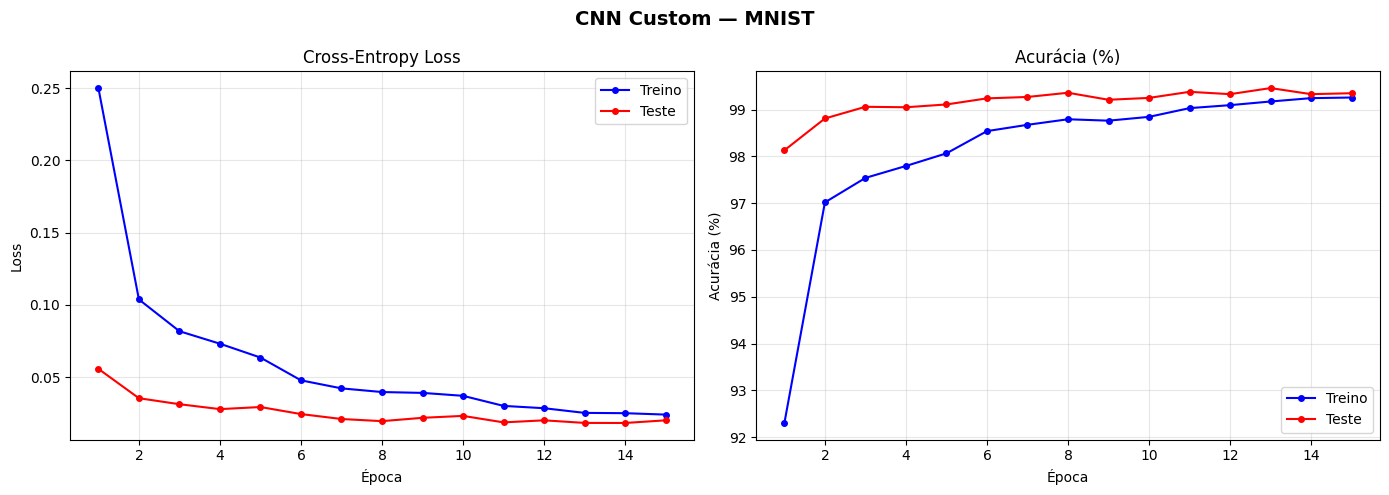

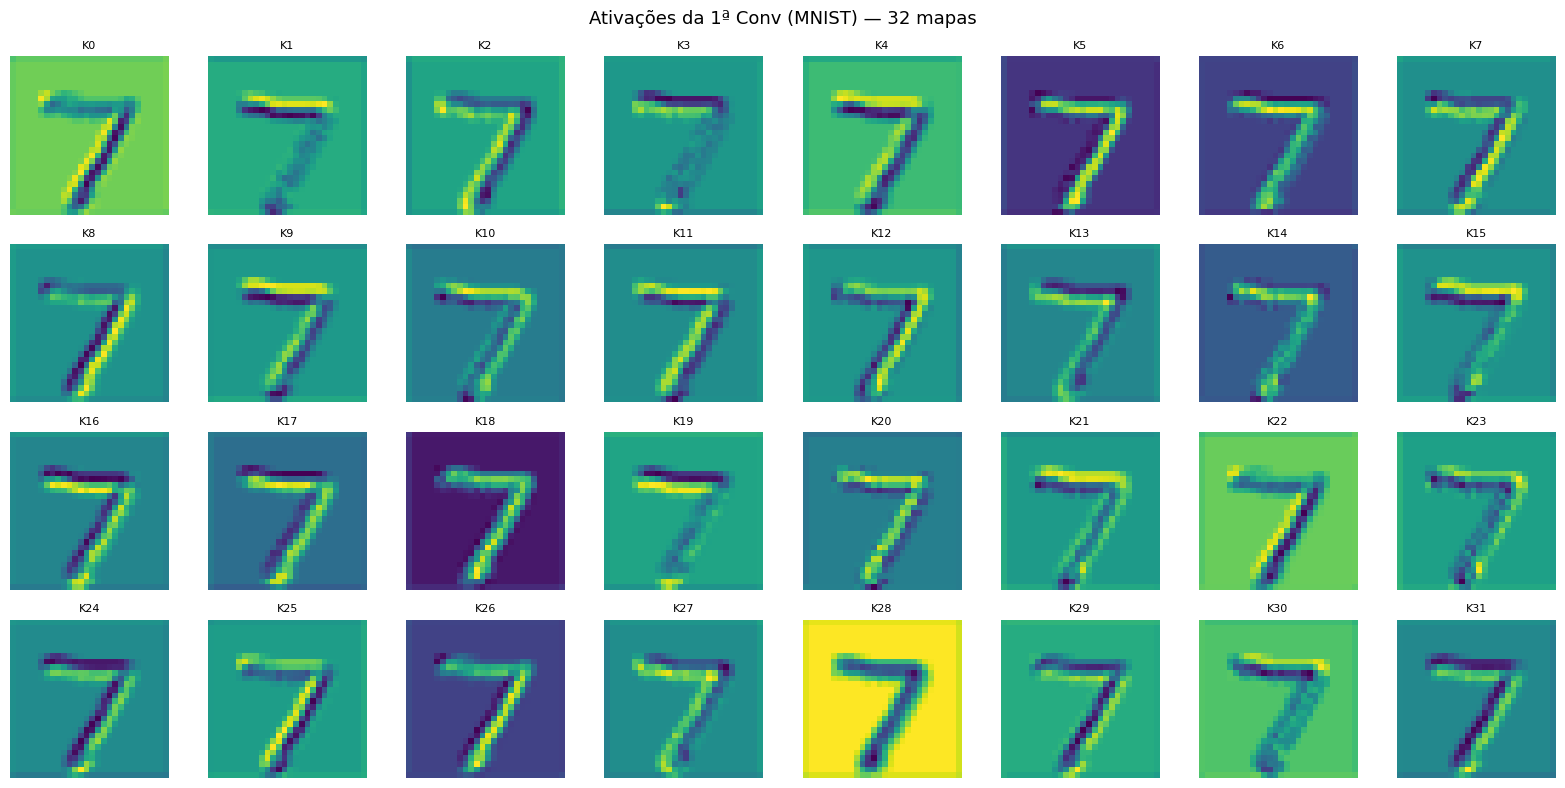

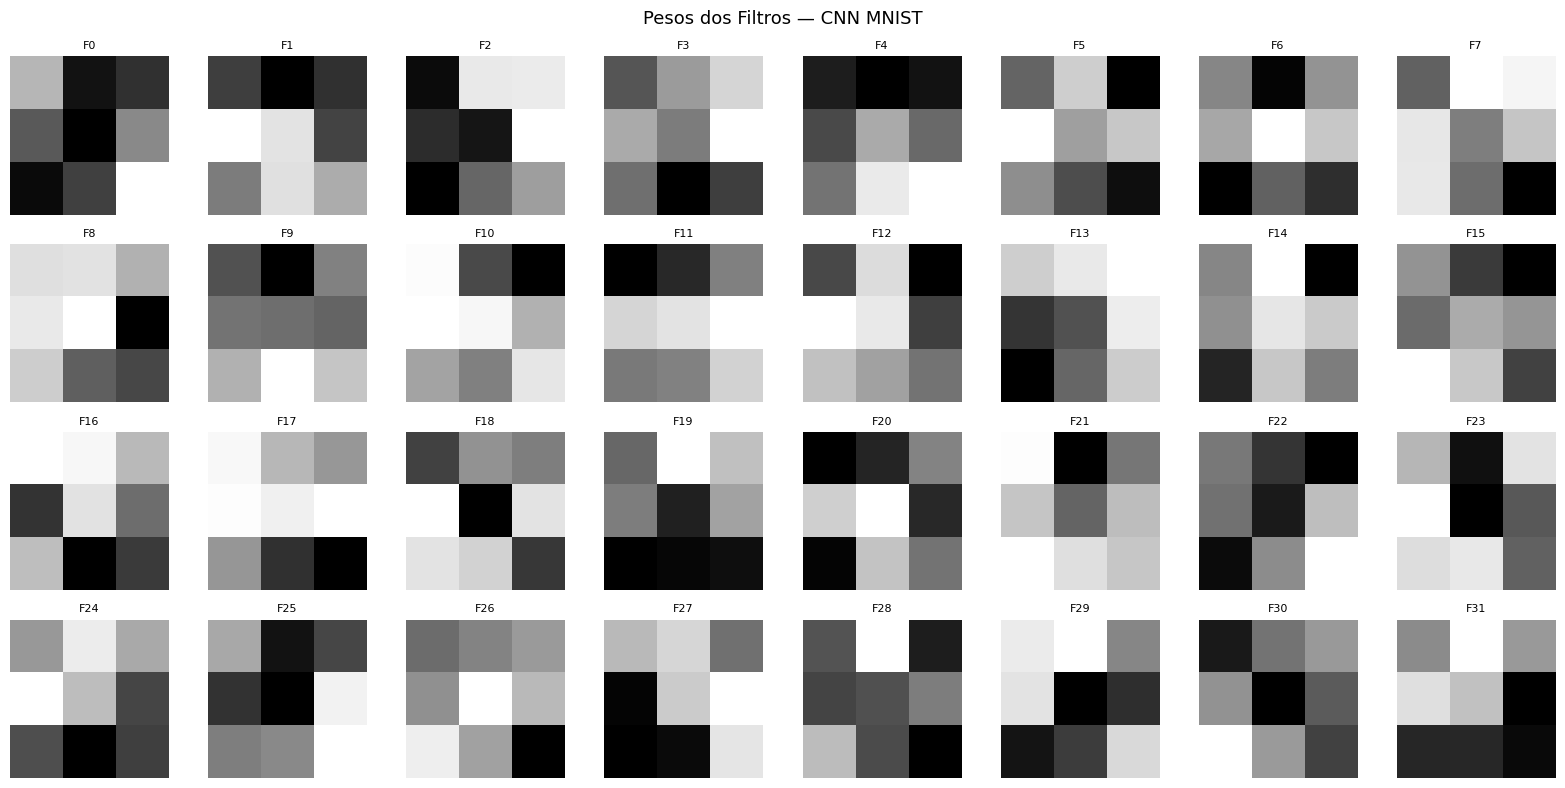


  EXPERIMENTO 2: CNN Custom — CIFAR-10


100%|██████████| 170M/170M [00:04<00:00, 37.7MB/s]


CNN_CIFAR10(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.3, inplace=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout2d(p=0.3, inplace=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Dropout2d(p=0.3, inplace=False)
  )
  (classifier): Sequential(
    (0):

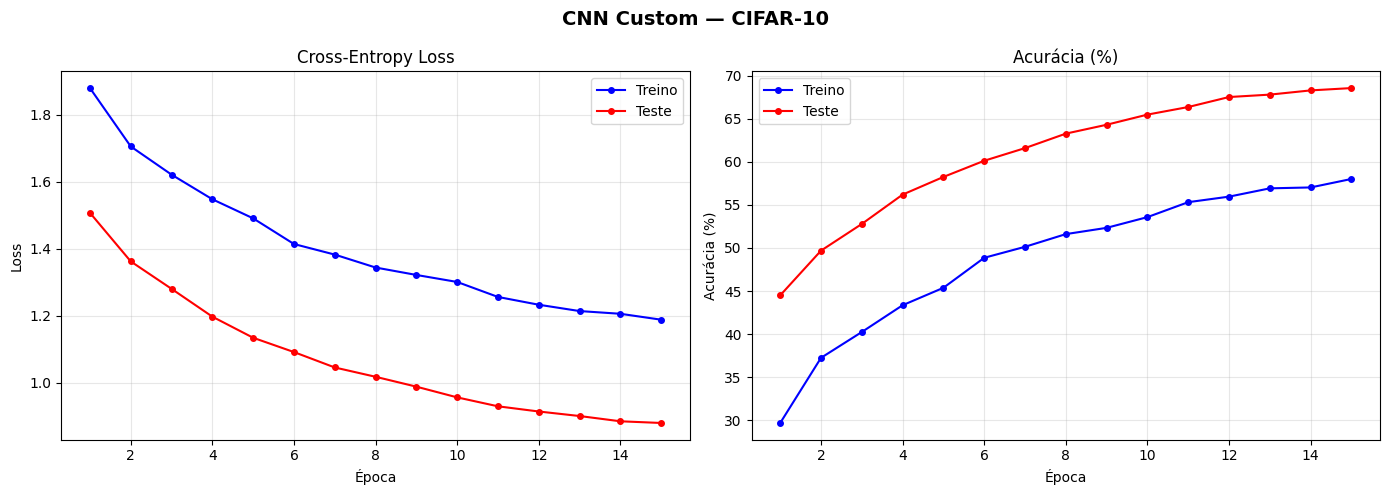

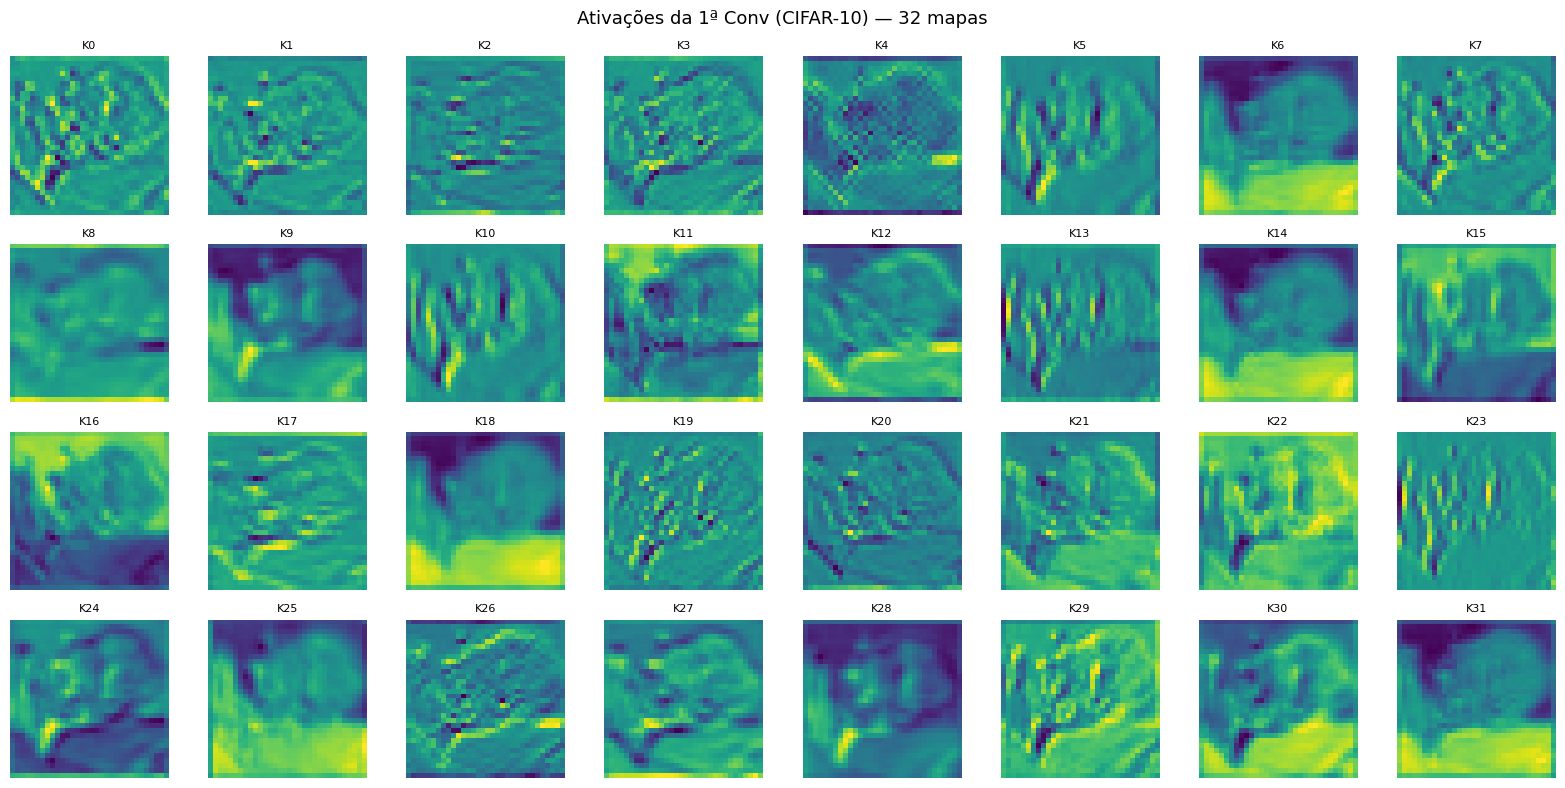

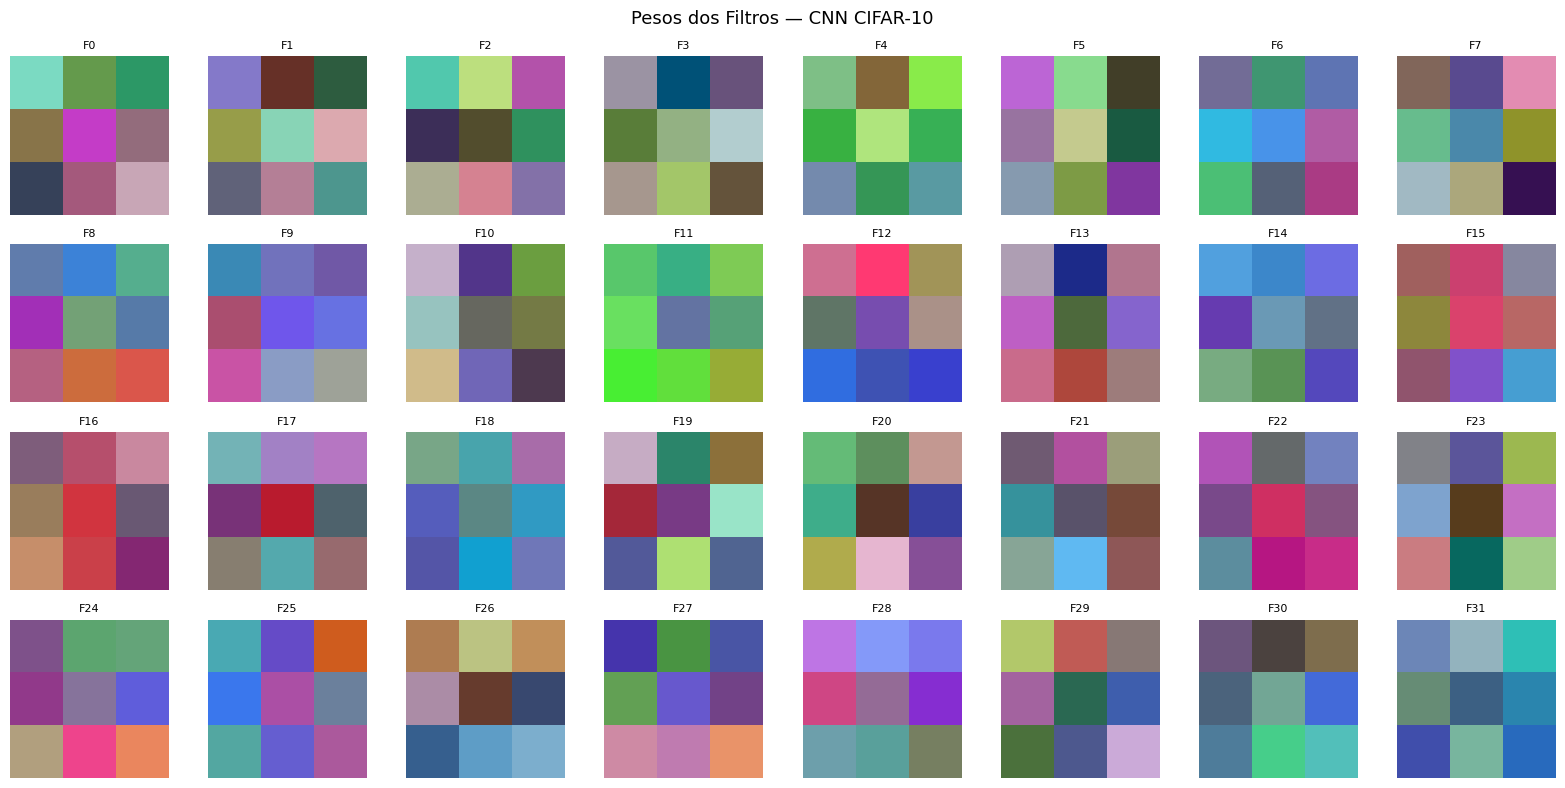


  EXPERIMENTO 3: ResNet50 (fine-tuning) — MNIST
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 187MB/s]


[ResNet50-MNIST] Época 01/5 | Loss Treino: 0.1131 | Acc Treino: 96.56% | Loss Teste: 0.0588 | Acc Teste: 98.11%
  ✔ Nova melhor acurácia: 98.11% — pesos salvos.
[ResNet50-MNIST] Época 02/5 | Loss Treino: 0.0670 | Acc Treino: 97.94% | Loss Teste: 0.0516 | Acc Teste: 98.39%
  ✔ Nova melhor acurácia: 98.39% — pesos salvos.
[ResNet50-MNIST] Época 03/5 | Loss Treino: 0.0564 | Acc Treino: 98.24% | Loss Teste: 0.0316 | Acc Teste: 98.99%
  ✔ Nova melhor acurácia: 98.99% — pesos salvos.
[ResNet50-MNIST] Época 04/5 | Loss Treino: 0.0458 | Acc Treino: 98.59% | Loss Teste: 0.0622 | Acc Teste: 98.13%
  ✘ Sem melhora (1/3). Melhor: 98.99%
[ResNet50-MNIST] Época 05/5 | Loss Treino: 0.0394 | Acc Treino: 98.83% | Loss Teste: 0.0459 | Acc Teste: 98.47%
  ✘ Sem melhora (2/3). Melhor: 98.99%


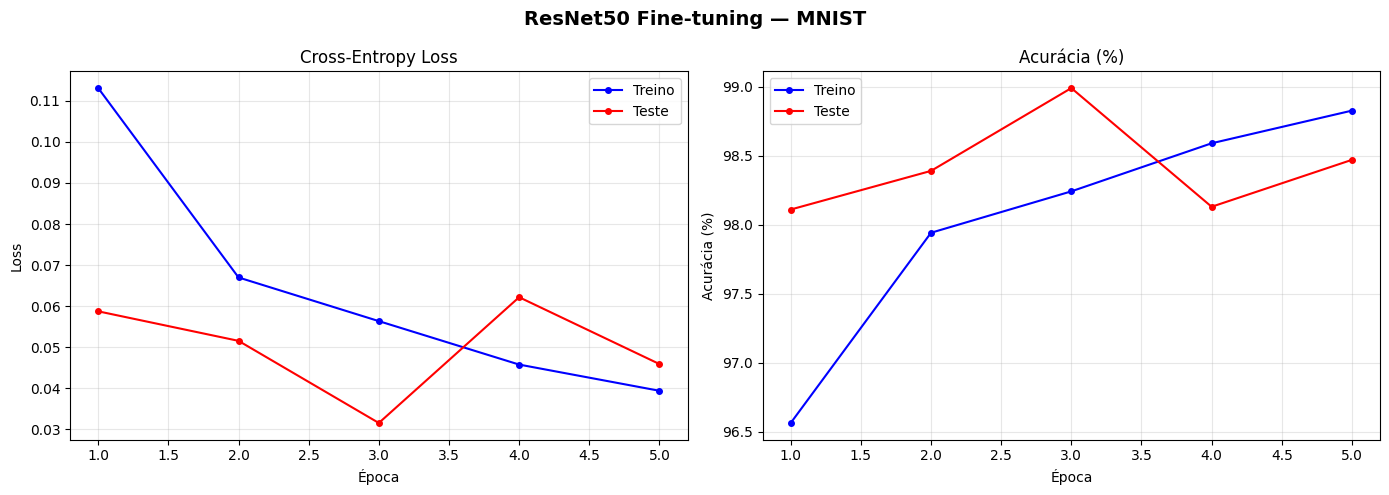


  EXPERIMENTO 4: ResNet50 (fine-tuning) — CIFAR-10
[ResNet50-CIFAR10] Época 01/5 | Loss Treino: 0.6386 | Acc Treino: 78.16% | Loss Teste: 0.4776 | Acc Teste: 83.56%
  ✔ Nova melhor acurácia: 83.56% — pesos salvos.
[ResNet50-CIFAR10] Época 02/5 | Loss Treino: 0.4440 | Acc Treino: 84.81% | Loss Teste: 0.5427 | Acc Teste: 82.48%
  ✘ Sem melhora (1/3). Melhor: 83.56%
[ResNet50-CIFAR10] Época 03/5 | Loss Treino: 0.4024 | Acc Treino: 86.12% | Loss Teste: 0.4446 | Acc Teste: 84.70%
  ✔ Nova melhor acurácia: 84.70% — pesos salvos.
[ResNet50-CIFAR10] Época 04/5 | Loss Treino: 0.3650 | Acc Treino: 87.54% | Loss Teste: 0.4134 | Acc Teste: 85.98%
  ✔ Nova melhor acurácia: 85.98% — pesos salvos.
[ResNet50-CIFAR10] Época 05/5 | Loss Treino: 0.3343 | Acc Treino: 88.57% | Loss Teste: 0.3795 | Acc Teste: 87.07%
  ✔ Nova melhor acurácia: 87.07% — pesos salvos.


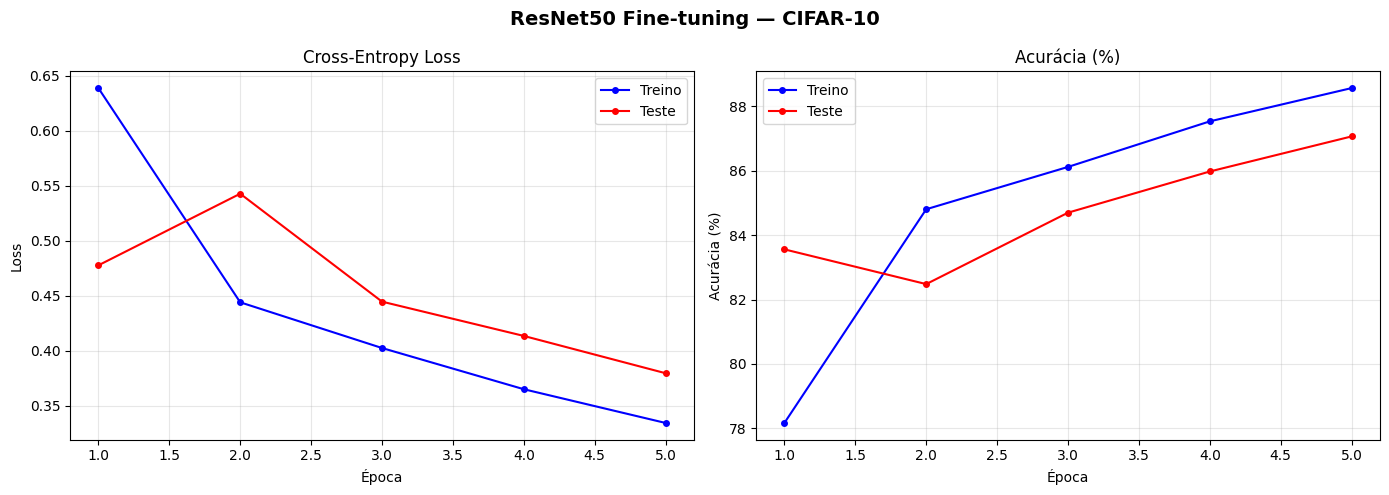


  COMPARAÇÃO FINAL DE MODELOS


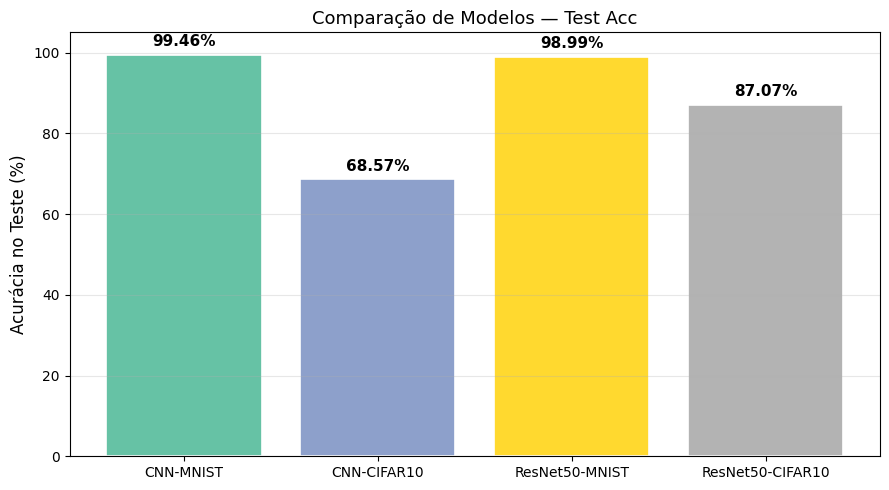


Modelo                Melhor Acc. Teste
----------------------------------------
CNN-MNIST                        99.46%
CNN-CIFAR10                      68.57%
ResNet50-MNIST                   98.99%
ResNet50-CIFAR10                 87.07%


In [10]:
if __name__ == "__main__":

    all_results = {}   # Armazena históricos para comparação final

    # ── 7.1 CNN CUSTOM — MNIST ────────────────────────────────────────────────
    print("\n" + "="*65)
    print("  EXPERIMENTO 1: CNN Custom — MNIST")
    print("="*65)

    mnist_train, mnist_test = get_mnist_loaders()
    cnn_mnist = CNN_MNIST().to(DEVICE)
    print(cnn_mnist)

    hist_mnist = train_model(cnn_mnist, mnist_train, mnist_test,
                             tag="CNN-MNIST", weight_decay=1e-4)
    plot_history(hist_mnist, "CNN Custom — MNIST")
    all_results["CNN-MNIST"] = hist_mnist

    # Visualizações do desafio
    sample_mnist, _ = next(iter(mnist_test))
    plot_kernel_activations(cnn_mnist, sample_mnist[0], "1ª Conv (MNIST)")
    plot_conv_weights(cnn_mnist, "Pesos dos Filtros — CNN MNIST")


    # ── 7.2 CNN CUSTOM — CIFAR-10 ─────────────────────────────────────────────
    print("\n" + "="*65)
    print("  EXPERIMENTO 2: CNN Custom — CIFAR-10")
    print("="*65)

    cifar_train, cifar_test = get_cifar10_loaders()
    cnn_cifar = CNN_CIFAR10().to(DEVICE)
    print(cnn_cifar)

    hist_cifar = train_model(cnn_cifar, cifar_train, cifar_test,
                             tag="CNN-CIFAR10", weight_decay=1e-4)
    plot_history(hist_cifar, "CNN Custom — CIFAR-10")
    all_results["CNN-CIFAR10"] = hist_cifar

    sample_cifar, _ = next(iter(cifar_test))
    plot_kernel_activations(cnn_cifar, sample_cifar[0], "1ª Conv (CIFAR-10)")
    plot_conv_weights(cnn_cifar, "Pesos dos Filtros — CNN CIFAR-10")


    # ── 7.3 BASELINE — ResNet50 no MNIST ─────────────────────────────────────
    print("\n" + "="*65)
    print("  EXPERIMENTO 3: ResNet50 (fine-tuning) — MNIST")
    print("="*65)

    res_mnist_train, res_mnist_test = get_resnet_loaders_mnist()
    resnet_mnist = build_resnet50_for(num_classes=10, grayscale=True)

    # Fine-tuning com 5 épocas (pesos pré-treinados já são ricos)
    hist_res_mnist = train_model(resnet_mnist, res_mnist_train, res_mnist_test,
                                 tag="ResNet50-MNIST", weight_decay=1e-4, epochs=5)
    plot_history(hist_res_mnist, "ResNet50 Fine-tuning — MNIST")
    all_results["ResNet50-MNIST"] = hist_res_mnist


    # ── 7.4 BASELINE — ResNet50 no CIFAR-10 ──────────────────────────────────
    print("\n" + "="*65)
    print("  EXPERIMENTO 4: ResNet50 (fine-tuning) — CIFAR-10")
    print("="*65)

    res_cifar_train, res_cifar_test = get_resnet_loaders_cifar10()
    resnet_cifar = build_resnet50_for(num_classes=10, grayscale=False)

    hist_res_cifar = train_model(resnet_cifar, res_cifar_train, res_cifar_test,
                                 tag="ResNet50-CIFAR10", weight_decay=1e-4, epochs=5)
    plot_history(hist_res_cifar, "ResNet50 Fine-tuning — CIFAR-10")
    all_results["ResNet50-CIFAR10"] = hist_res_cifar


    # ── 7.5 GRÁFICO DE COMPARAÇÃO FINAL ──────────────────────────────────────
    print("\n" + "="*65)
    print("  COMPARAÇÃO FINAL DE MODELOS")
    print("="*65)

    plot_comparison(all_results, metric="test_acc")

    # Tabela textual de resultados
    print(f"\n{'Modelo':<20} {'Melhor Acc. Teste':>18}")
    print("-" * 40)
    for name, hist in all_results.items():
        best_acc = max(hist["test_acc"]) * 100
        print(f"{name:<20} {best_acc:>17.2f}%")
